In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from astropy.coordinates import get_body
from astropy.time import Time

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)

def _ha_fmt(deg, pos=None):
    """Format decimal degrees as LaTeX $±HH^h MM^m$ (hour angle, no seconds)."""
    sign = '-' if deg < 0 else '+'
    h_abs = abs(deg) / 15.0
    hh = int(h_abs)
    mm = round((h_abs - hh) * 60)
    if mm == 60:
        hh += 1; mm = 0
    return rf'${sign}{hh}^h\,{mm:02d}^m$'

HA_FMT = mticker.FuncFormatter(_ha_fmt)

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data/lab03/moon_calibration')
PLOT_BAND_GHZ = (9.9, 10.0)

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {len(files)} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

all_amp                  = np.array([np.abs(f['corr']) for f in files]).astype(float)
all_amp[:, BAD_CHANNELS] = np.nan

print(f'Masked : {BAD_CHANNELS}  '
      f'({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# ── Normalise ─────────────────────────────────────────────────────────────
AMP_PEAK = np.nanmax(all_amp)
print(f'Peak   : {AMP_PEAK:.4f}  (max of unmasked channels across all captures)')

Loaded 59 captures  |  9.7900 -- 10.0398 GHz  |  244.1 kHz/ch
Masked : [0, 256, 512, 768]  (['9.7900 GHz', '9.8525 GHz', '9.9150 GHz', '9.9775 GHz'])
Peak   : 1.0897  (max of unmasked channels across all captures)


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# The Moon's RA changes ~0.5 deg/hr so it must be recomputed per capture.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    """Midpoint unix timestamp; falls back to legacy 'unix_time' key."""
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

def _moon_ra_deg(unix_t):
    """Moon's RA in degrees at the given unix time."""
    return get_body('moon', Time(unix_t, format='unix')).ra.deg

# Sort files by mid-capture unix time
unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[j]  for j in order]
paths_s   = [paths[j]  for j in order]

lst_arr      = np.array([_lst_deg(t)    for t in unix_sort])
moon_ra_arr  = np.array([_moon_ra_deg(t) for t in unix_sort])
ha_deg       = (lst_arr - moon_ra_arr) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

# Peak channel within PLOT_BAND_GHZ (excluding artifact channels)
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([f['corr'][k_peak] for f in files_s])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

print(f'Moon RA  : {moon_ra_arr.min():.4f} -- {moon_ra_arr.max():.4f} deg  '
      f'(span {moon_ra_arr.max()-moon_ra_arr.min():.4f} deg)')
print(f'HA range : {ha_deg.min():.2f}° -> {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')

Moon RA  : 352.2053 -- 352.3145 deg  (span 0.1093 deg)
HA range : -73.93° -> -70.82°  (3.12° span)
Peak channel : k=577,  f_sky=9.9309 GHz
Amp  (norm)  : mean=0.768,  std=0.058
Phase        : mean=172.2°,  std=46.2°


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_61947/729967123.py:40: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


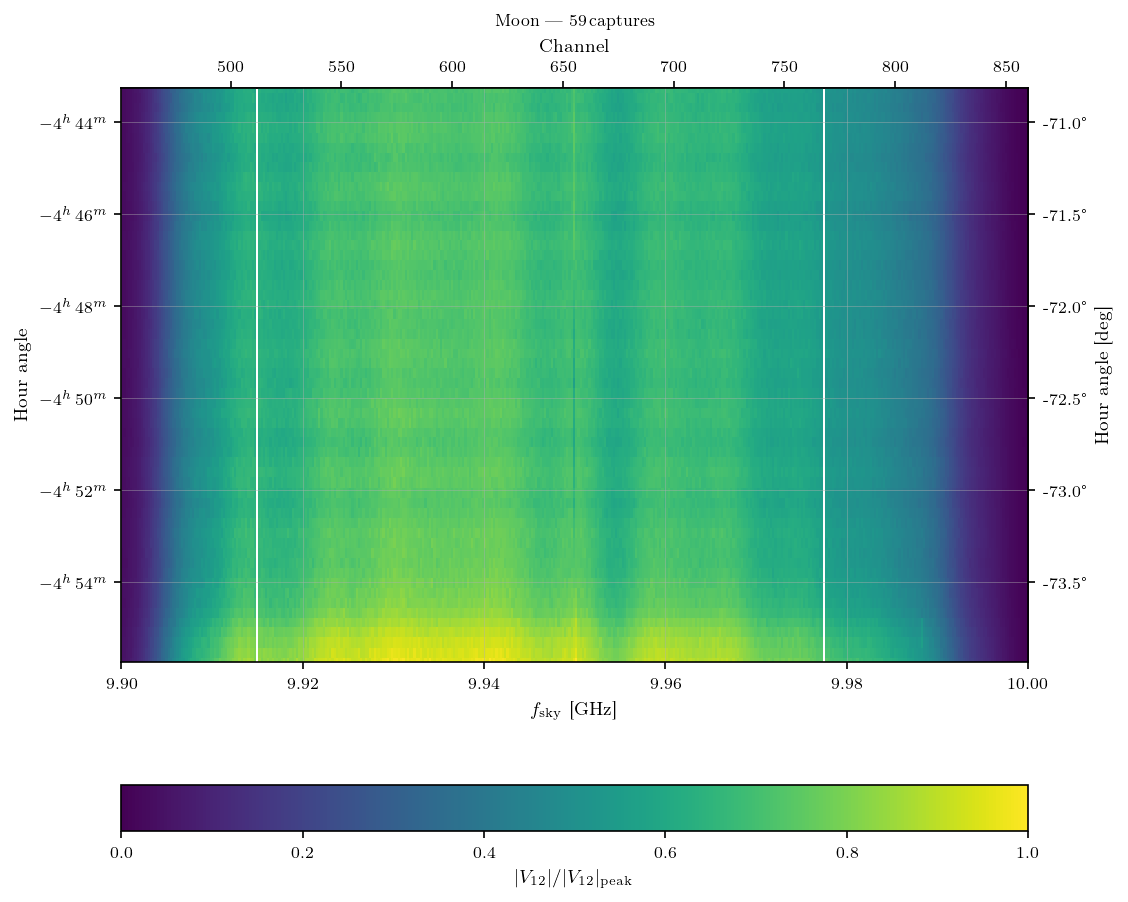

In [4]:
# ---------------------------------------------------------------------------
# Waterfall (spectrogram): f_sky vs hour angle
# ---------------------------------------------------------------------------

amp_matrix = np.array([np.abs(f['corr']) / AMP_PEAK for f in files_s]).astype(float)
amp_matrix[:, BAD_CHANNELS] = np.nan

fig_height = (ha_deg.max() - ha_deg.min()) / 2.5 * 60 / 12
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, fig_height))

im = ax.pcolormesh(
    F_SKY_GHZ,
    ha_deg,
    amp_matrix,
    vmin=0, vmax=1,
    cmap='viridis',
    shading='auto',
)
ax.set_xlim(*PLOT_BAND_GHZ)
ax.set_ylim(ha_deg.min(), ha_deg.max())
ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
ax.set_ylabel('Hour angle')
ax.set_title(rf'Moon --- {len(files_s)}\,captures', fontsize=TICK_SIZE)
ax.yaxis.set_major_formatter(HA_FMT)
ax2 = ax.secondary_yaxis('right', functions=(lambda x: x, lambda x: x))
ax2.set_ylabel('Hour angle [deg]')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.1f}°'))
ax_top = ax.secondary_xaxis('top', functions=(
    lambda ghz: (ghz * 1e9 - F_RF0_HZ) / DF_HZ,
    lambda k: (k * DF_HZ + F_RF0_HZ) / 1e9,
))
ax_top.set_xlabel('Channel')
fig.colorbar(im, ax=ax, label=r'$|V_{12}| / |V_{12}|_{\rm peak}$', location='bottom')

fig.tight_layout()
plt.show()


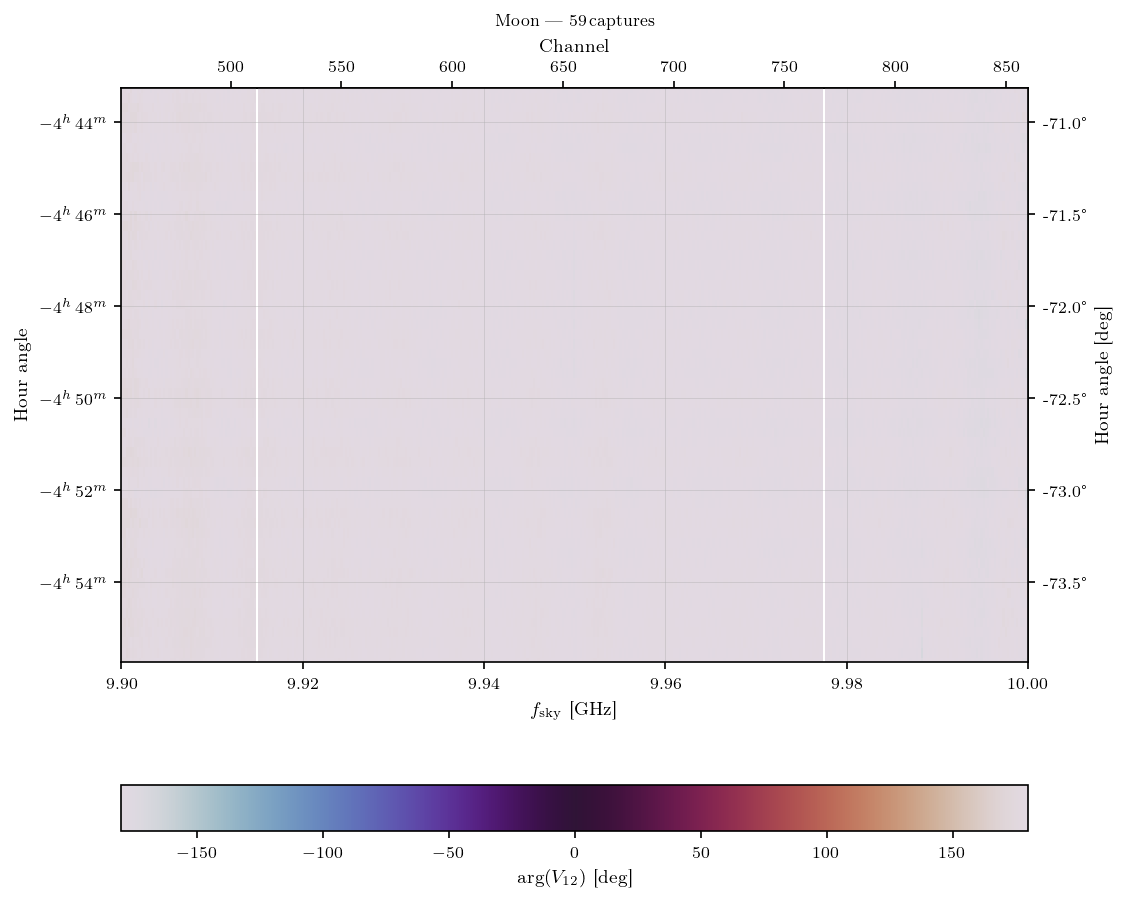

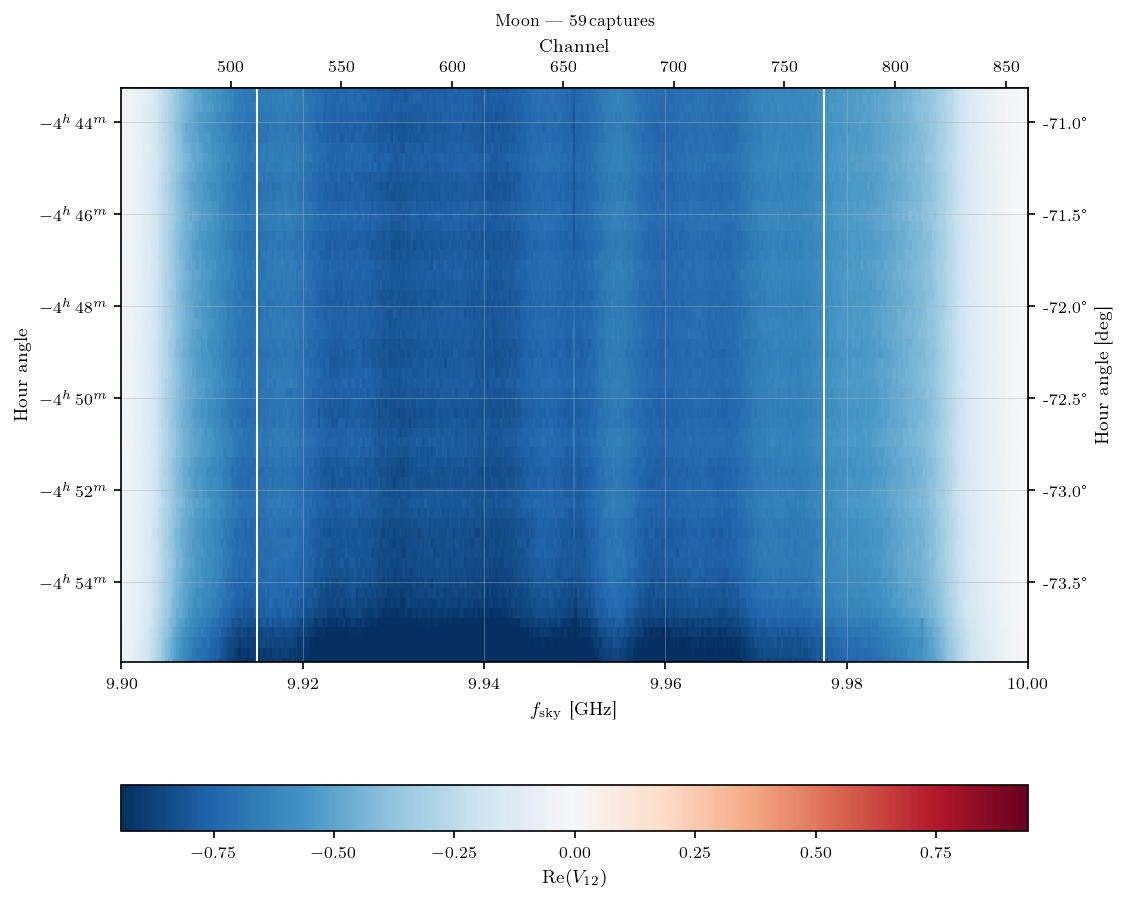

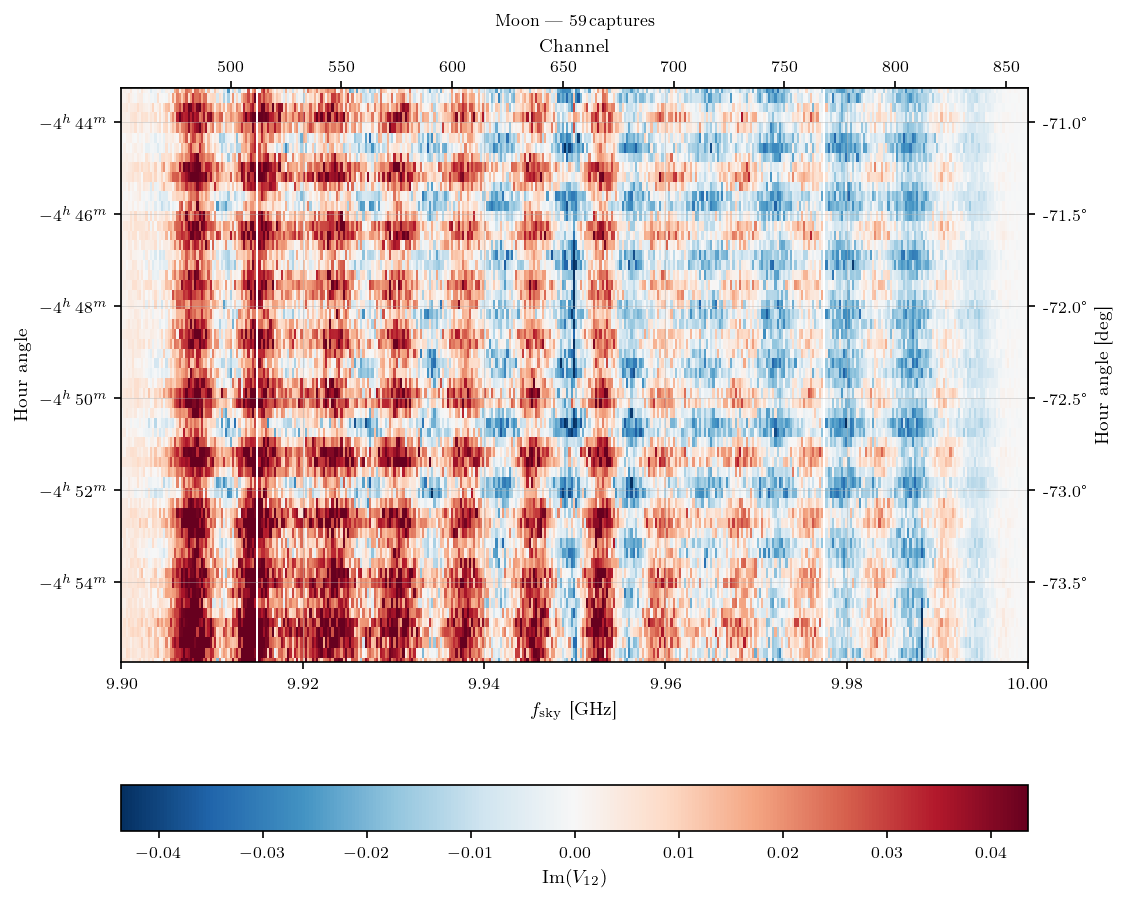

In [5]:
# ---------------------------------------------------------------------------
# Waterfalls: arg(V_12),  Re(V_12),  Im(V_12)  — f_sky vs hour angle
# ---------------------------------------------------------------------------

_wf_configs = [
    ('arg',  r'$\arg(V_{12})$ [deg]',  'twilight', -180, 180),
    ('re',   r'$\mathrm{Re}(V_{12})$', 'RdBu_r',   None, None),
    ('im',   r'$\mathrm{Im}(V_{12})$', 'RdBu_r',   None, None),
]

for kind, cbar_label, cmap, vmin_fixed, vmax_fixed in _wf_configs:
    rows = []
    for f in files_s:
        c = f['corr'].astype(complex)
        if kind == 'arg':
            row = np.rad2deg(np.angle(c))
        elif kind == 're':
            row = c.real
        else:
            row = c.imag
        row = row.copy()
        row[BAD_CHANNELS] = np.nan
        rows.append(row)
    mat = np.array(rows)

    if vmin_fixed is None:
        vabs = np.nanpercentile(np.abs(mat), 99)
        vmin, vmax = -vabs, vabs
    else:
        vmin, vmax = vmin_fixed, vmax_fixed

    fig_height = (ha_deg.max() - ha_deg.min()) / 2.5 * 60 / 12
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, fig_height))

    im = ax.pcolormesh(
        F_SKY_GHZ,
        ha_deg,
        mat,
        vmin=vmin, vmax=vmax,
        cmap=cmap, shading='auto',
    )
    ax.set_xlim(*PLOT_BAND_GHZ)
    ax.set_ylim(ha_deg.min(), ha_deg.max())
    ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
    ax.set_ylabel('Hour angle')
    ax.set_title(rf'Moon --- {len(files_s)}\,captures', fontsize=TICK_SIZE)
    ax.yaxis.set_major_formatter(HA_FMT)
    ax2 = ax.secondary_yaxis('right', functions=(lambda x: x, lambda x: x))
    ax2.set_ylabel('Hour angle [deg]')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.1f}°'))
    ax_top = ax.secondary_xaxis('top', functions=(
        lambda ghz: (ghz * 1e9 - F_RF0_HZ) / DF_HZ,
        lambda k: (k * DF_HZ + F_RF0_HZ) / 1e9,
    ))
    ax_top.set_xlabel('Channel')
    fig.colorbar(im, ax=ax, label=cbar_label, location='bottom')

    fig.tight_layout()
    plt.show()


Captures        : 59
Wall-clock span : 782.4 s  (13.0 min)
On-sky total    : 624.9 s  (10.4 min)
Duty cycle      : 79.9%
n_acc per cap   : min=9  mean=9.6  max=10
Gap (s)         : min=2.65  median=2.70  mean=2.72  max=3.29


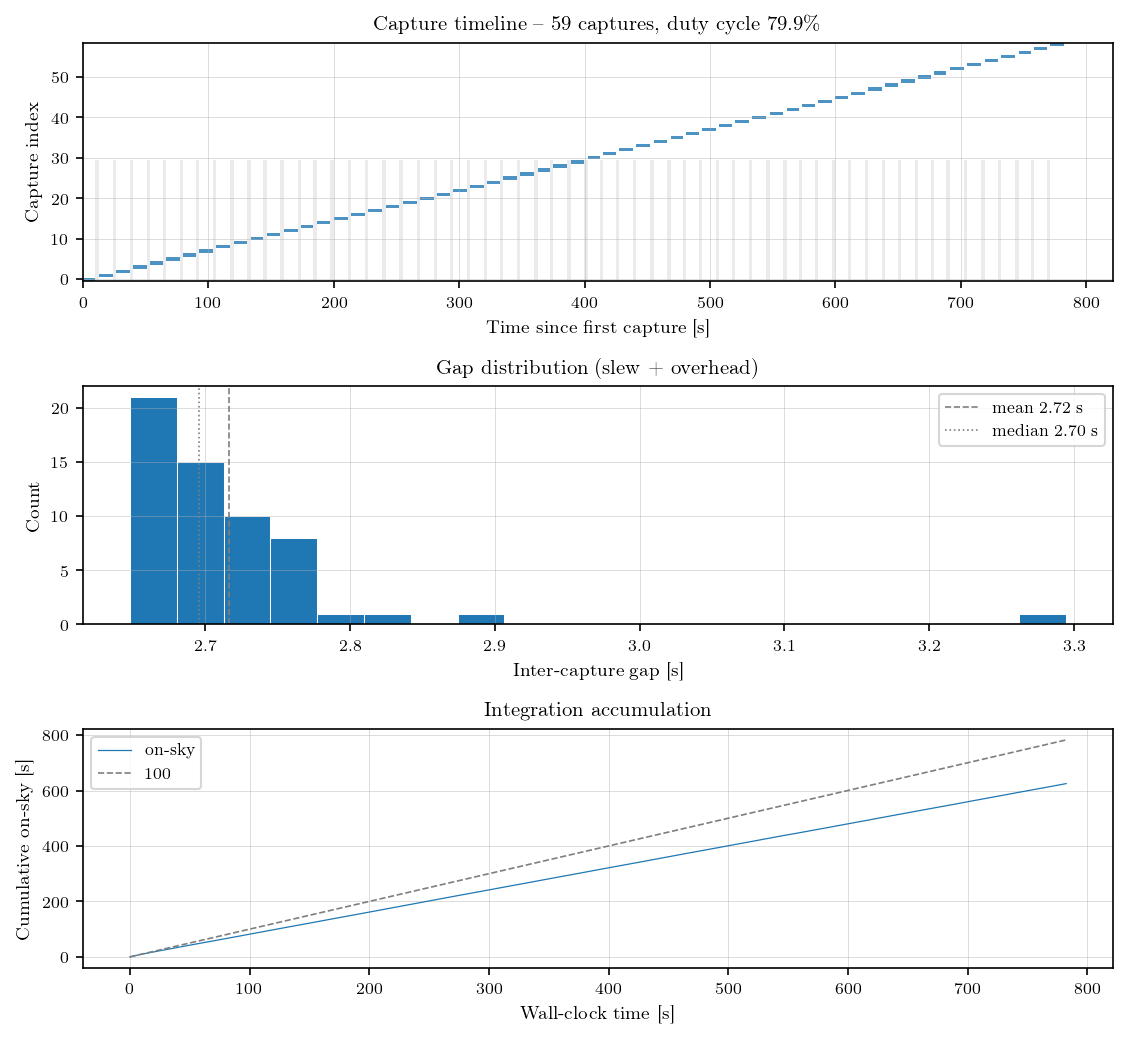

In [6]:
# ---------------------------------------------------------------------------
# Integration time coverage
# ---------------------------------------------------------------------------

t_start = np.array([float(f['unix_time_start']) for f in files_s])
t_end   = np.array([float(f['unix_time_end'])   for f in files_s])
n_acc   = np.array([int(f['n_acc'])             for f in files_s])
durs    = t_end - t_start
gaps    = t_start[1:] - t_end[:-1]
t0      = t_start[0]

total_wall = t_end[-1] - t_start[0]
total_sky  = durs.sum()
duty       = total_sky / total_wall * 100

print(f'Captures        : {len(files_s)}')
print(f'Wall-clock span : {total_wall:.1f} s  ({total_wall/60:.1f} min)')
print(f'On-sky total    : {total_sky:.1f} s  ({total_sky/60:.1f} min)')
print(f'Duty cycle      : {duty:.1f}%')
print(f'n_acc per cap   : min={n_acc.min()}  mean={n_acc.mean():.1f}  max={n_acc.max()}')
print(f'Gap (s)         : min={gaps.min():.2f}  median={np.median(gaps):.2f}  mean={gaps.mean():.2f}  max={gaps.max():.2f}')

# ── 1. Gantt timeline ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 7))

ax = axes[0]
for i, (ts, te) in enumerate(zip(t_start - t0, t_end - t0)):
    ax.barh(i, te - ts, left=ts, height=0.8, color=PRIMARY_COLOR, alpha=0.8)
for ts, te in zip(t_end[:-1] - t0, t_start[1:] - t0):
    ax.barh(0, te - ts, left=ts, height=len(files_s),
            color=NEUTRAL_COLOR, alpha=0.15, zorder=0)
ax.set_xlabel('Time since first capture [s]')
ax.set_ylabel('Capture index')
ax.set_title(rf'Capture timeline -- {len(files_s)} captures, duty cycle {duty:.1f}\%')
ax.set_ylim(-0.5, len(files_s) - 0.5)

# ── 2. Gap histogram ───────────────────────────────────────────────────────
ax = axes[1]
ax.hist(gaps, bins=20, color=PRIMARY_COLOR, edgecolor='white', linewidth=0.5)
ax.axvline(gaps.mean(),     color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--',
           label=rf'mean {gaps.mean():.2f} s')
ax.axvline(np.median(gaps), color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':',
           label=rf'median {np.median(gaps):.2f} s')
ax.set_xlabel('Inter-capture gap [s]')
ax.set_ylabel('Count')
ax.set_title('Gap distribution (slew + overhead)')
ax.legend(fontsize=TICK_SIZE)

# ── 3. Cumulative integration vs wall-clock ────────────────────────────────
ax = axes[2]
t_wall = np.concatenate([[0], t_end   - t0])
t_sky  = np.concatenate([[0], np.cumsum(durs)])
ax.plot(t_wall, t_sky,   color=PRIMARY_COLOR, lw=LW_FINE, label='on-sky')
ax.plot([0, t_wall[-1]], [0, t_wall[-1]],
        color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--', label='100 % duty')
ax.set_xlabel('Wall-clock time [s]')
ax.set_ylabel('Cumulative on-sky [s]')
ax.set_title('Integration accumulation')
ax.legend(fontsize=TICK_SIZE)

fig.tight_layout()
plt.show()

/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_61947/114421021.py:9: RuntimeWarning: Mean of empty slice
  re_mean = np.nanmean(corr_matrix.real, axis=0)   # per-channel DC estimate


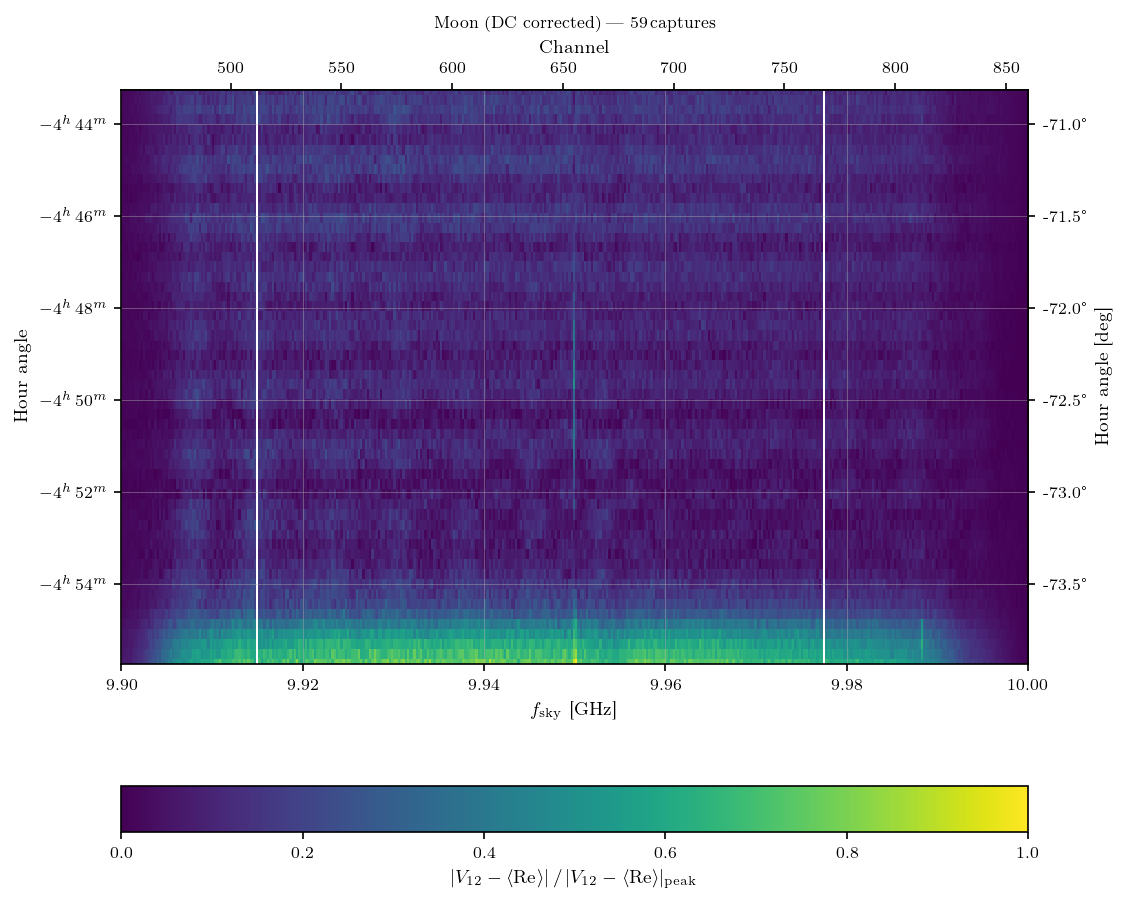

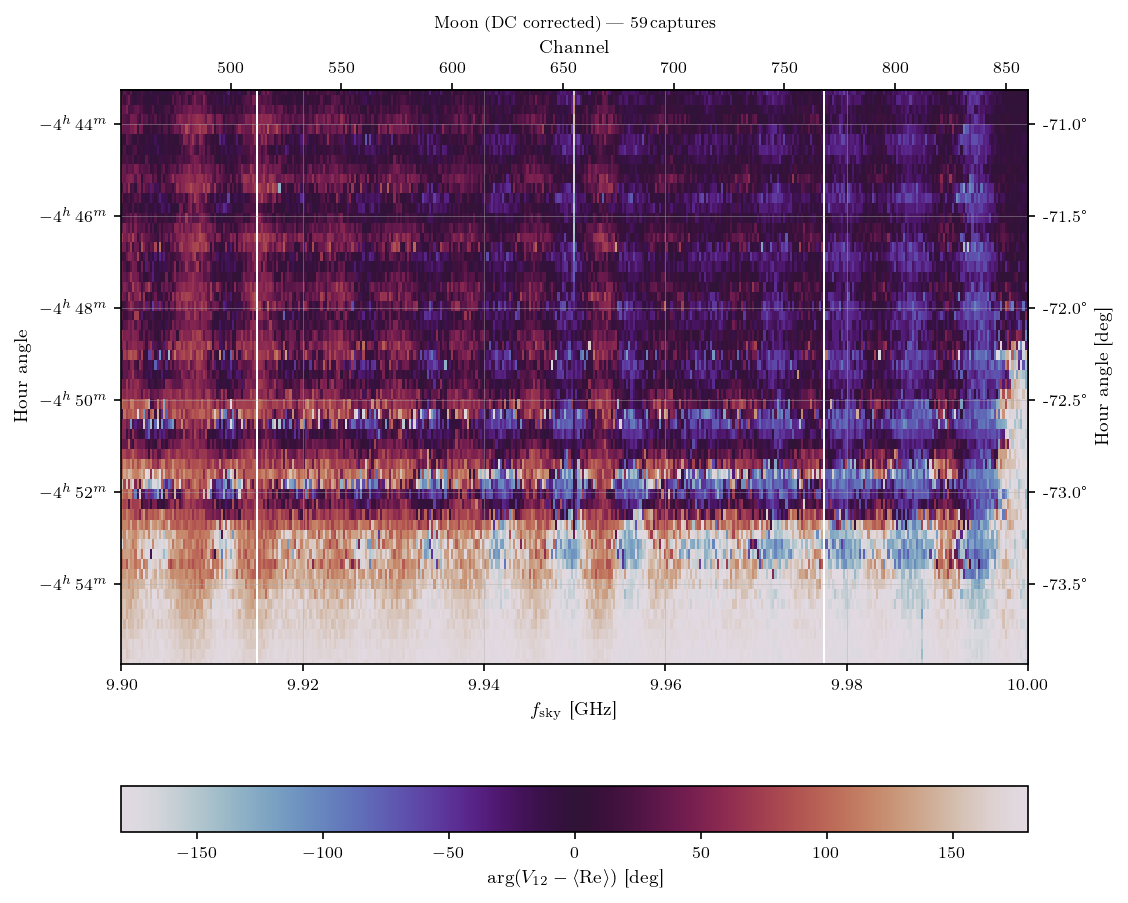

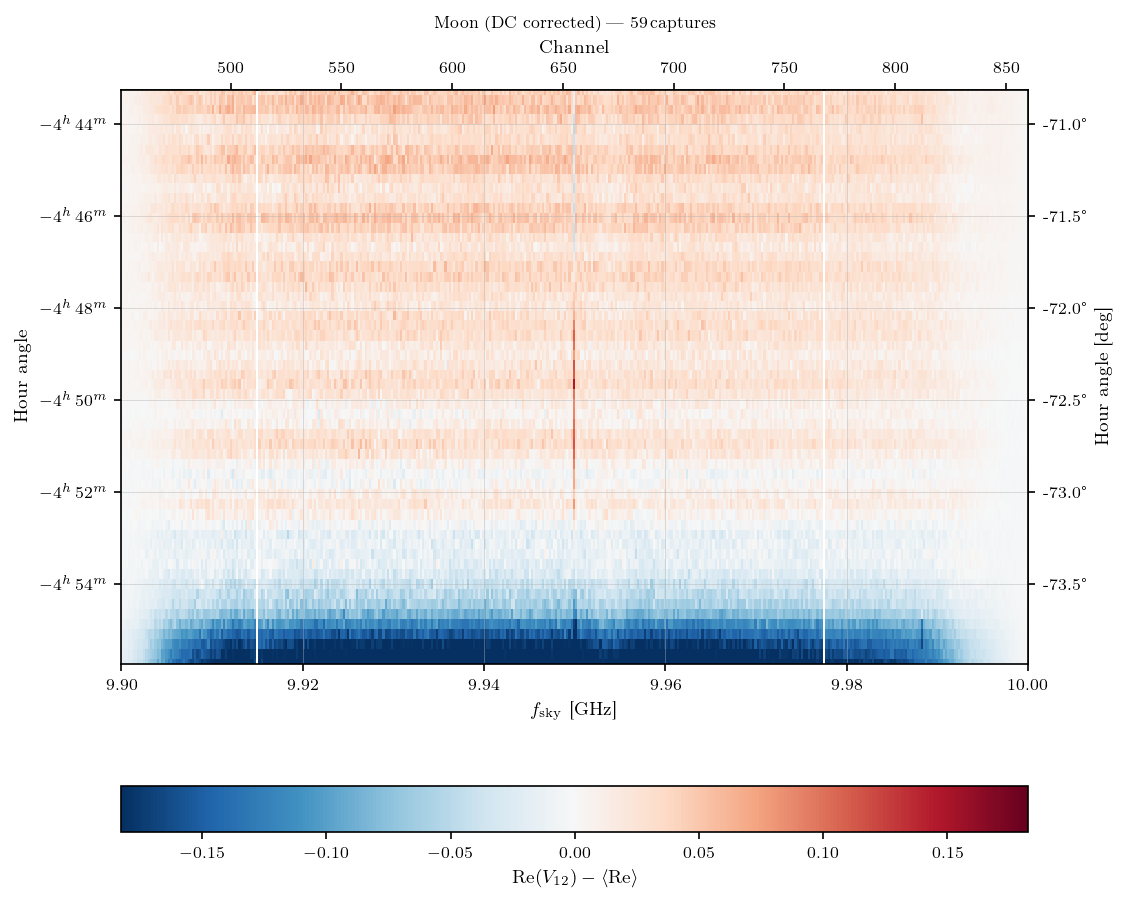

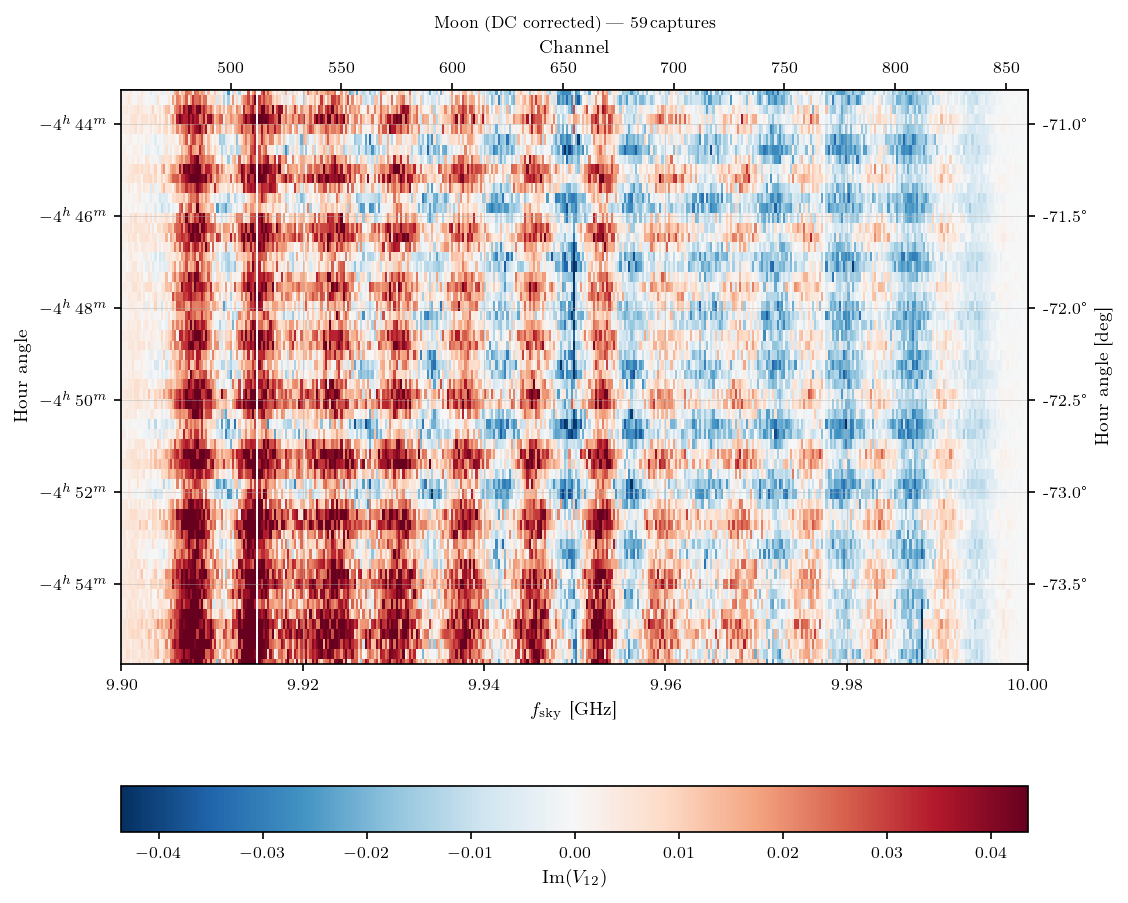

In [7]:
# ---------------------------------------------------------------------------
# DC offset correction: subtract per-channel mean of Re across all captures,
# then replot amp, arg, Re, Im waterfalls (f_sky vs hour angle)
# ---------------------------------------------------------------------------

corr_matrix = np.array([f['corr'].astype(complex) for f in files_s])  # (N, N_CH)
corr_matrix[:, BAD_CHANNELS] = np.nan

re_mean = np.nanmean(corr_matrix.real, axis=0)   # per-channel DC estimate
corr_dc  = corr_matrix - re_mean[np.newaxis, :]  # subtract from Re only

amp_dc      = np.abs(corr_dc)
amp_dc_peak = np.nanmax(amp_dc)

_wf_configs_dc = [
    ('amp', r'$|V_{12} - \langle\mathrm{Re}\rangle|\,/\,|V_{12} - \langle\mathrm{Re}\rangle|_{\rm peak}$',
            'viridis', 0, 1),
    ('arg',  r'$\arg(V_{12} - \langle\mathrm{Re}\rangle)$ [deg]', 'twilight', -180, 180),
    ('re',   r'$\mathrm{Re}(V_{12}) - \langle\mathrm{Re}\rangle$', 'RdBu_r',  None, None),
    ('im',   r'$\mathrm{Im}(V_{12})$',                             'RdBu_r',  None, None),
]

for kind, cbar_label, cmap, vmin_fixed, vmax_fixed in _wf_configs_dc:
    if kind == 'amp':
        mat = amp_dc / amp_dc_peak
    elif kind == 'arg':
        mat = np.rad2deg(np.angle(corr_dc))
    elif kind == 're':
        mat = corr_dc.real
    else:
        mat = corr_dc.imag

    if vmin_fixed is None:
        vabs = np.nanpercentile(np.abs(mat), 99)
        vmin, vmax = -vabs, vabs
    else:
        vmin, vmax = vmin_fixed, vmax_fixed

    fig_height = (ha_deg.max() - ha_deg.min()) / 2.5 * 60 / 12
    fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, fig_height))
    im = ax.pcolormesh(
        F_SKY_GHZ, ha_deg, mat,
        vmin=vmin, vmax=vmax, cmap=cmap, shading='auto',
    )
    ax.set_xlim(*PLOT_BAND_GHZ)
    ax.set_ylim(ha_deg.min(), ha_deg.max())
    ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
    ax.set_ylabel('Hour angle')
    ax.set_title(rf'Moon (DC corrected) --- {len(files_s)}\,captures', fontsize=TICK_SIZE)
    ax.yaxis.set_major_formatter(HA_FMT)
    ax2 = ax.secondary_yaxis('right', functions=(lambda x: x, lambda x: x))
    ax2.set_ylabel('Hour angle [deg]')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.1f}°'))
    ax_top = ax.secondary_xaxis('top', functions=(
        lambda ghz: (ghz * 1e9 - F_RF0_HZ) / DF_HZ,
        lambda k: (k * DF_HZ + F_RF0_HZ) / 1e9,
    ))
    ax_top.set_xlabel('Channel')
    fig.colorbar(im, ax=ax, label=cbar_label, location='bottom')
    fig.tight_layout()
    plt.show()
